In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


class SublamPRNN(nn.Module):
    def __init__(self, input_dim=6, nplies=4, out_dim_per_ply=6, hidden_dim=64):
        super().__init__()
        self.input_dim = input_dim
        self.nplies = nplies
        self.out_dim_per_ply = out_dim_per_ply

        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )

        self.ply_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, out_dim_per_ply)
            )
            for _ in range(nplies)
        ])

    def forward(self, strain):
        h = self.shared(strain)
        ply_outputs = [head(h) for head in self.ply_heads]
        out = torch.stack(ply_outputs, dim=1)
        return out

In [16]:
def generate_dataset(material_obj, n_samples=2000, strain_min=-0.02, strain_max=0.02):
    X = []
    Y = []

    for _ in range(n_samples):
        strain = np.random.uniform(strain_min, strain_max, size=6)
        sublamsig, _ = material_obj.sublam_sig_str(strain)

        X.append(strain)
        Y.append(sublamsig)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    return X, Y

In [17]:
from sublam_mat import material


IM7 = material(E11=161, E22=10, E33=10, v12=0.3, v13=0.3, v23=0.43, G12=5, G13=5, G23=3.4)
IM7.plymat()
IM7.materialvec()

In [18]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim



X, Y = generate_dataset(IM7, n_samples=3000, strain_min=-0.01, strain_max=0.01)

X_train = torch.tensor(X, dtype=torch.float32)
Y_train = torch.tensor(Y, dtype=torch.float32)

model = SublamPRNN(input_dim=6, nplies=4, out_dim_per_ply=6, hidden_dim=64)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 2000

for epoch in range(n_epochs):
    optimizer.zero_grad()

    Y_pred = model(X_train)
    loss = criterion(Y_pred, Y_train)

    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss.item():.6e}")

Epoch    0 | Loss = 1.441382e-01
Epoch  200 | Loss = 3.785640e-02
Epoch  400 | Loss = 1.372031e-03
Epoch  600 | Loss = 7.536830e-04
Epoch  800 | Loss = 2.097913e-04
Epoch 1000 | Loss = 1.309664e-04
Epoch 1200 | Loss = 7.184494e-05
Epoch 1400 | Loss = 1.958383e-05
Epoch 1600 | Loss = 1.406498e-05
Epoch 1800 | Loss = 3.194537e-04


In [19]:
strain_test = np.array([0.01, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
strain_test_torch = torch.tensor(strain_test).unsqueeze(0)

with torch.no_grad():
    pred_sublamsig = model(strain_test_torch).squeeze(0).numpy()

true_sublamsig, true_sublamstr = IM7.sublam_sig_str(strain_test)

print("Predicted sublamsig:")
print(pred_sublamsig)

print("\nTrue sublamsig:")
print(true_sublamsig)

Predicted sublamsig:
[[ 1.6384929e+00  5.2572981e-02  5.3888798e-02  1.2778980e-04
   8.7209046e-06  5.5908039e-04]
 [ 8.4953529e-01  8.9206353e-02  5.4190397e-02 -4.9970053e-02
  -3.7755817e-05 -4.2021275e-06]
 [ 5.4126058e-02  1.2459650e-01  5.4431468e-02 -1.9523315e-05
  -3.9767474e-06  6.9297850e-05]
 [ 8.4999967e-01  8.9375153e-02  5.4453436e-02  4.9986586e-02
  -1.0665506e-04  1.6230438e-04]]

True sublamsig:
[[ 1.64221070e+00  5.36845603e-02  5.36845603e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 8.47947630e-01  8.90619309e-02  5.40968967e-02 -4.99999989e-02
   0.00000000e+00  0.00000000e+00]
 [ 5.36845603e-02  1.24439301e-01  5.45092330e-02 -6.12323386e-18
   0.00000000e+00  0.00000000e+00]
 [ 8.47947630e-01  8.90619309e-02  5.40968967e-02  4.99999989e-02
   0.00000000e+00  0.00000000e+00]]


Epoch    0 | train = 5.606754e-01 | strain = 2.763298e-19 | stress = 5.606754e-01 | test = 5.616841e-01
Epoch  200 | train = 5.999048e-02 | strain = 2.763298e-19 | stress = 5.999048e-02 | test = 5.736261e-02
Epoch  400 | train = 3.123154e-03 | strain = 2.763298e-19 | stress = 3.123154e-03 | test = 3.101391e-03
Epoch  600 | train = 6.003859e-04 | strain = 2.763298e-19 | stress = 6.003859e-04 | test = 5.700244e-04
Epoch  800 | train = 3.807357e-04 | strain = 2.763298e-19 | stress = 3.807357e-04 | test = 3.377589e-04
Epoch 1000 | train = 1.098526e-05 | strain = 2.763298e-19 | stress = 1.098526e-05 | test = 1.101400e-05
Epoch 1200 | train = 4.680038e-06 | strain = 2.763298e-19 | stress = 4.680038e-06 | test = 5.053049e-06
Epoch 1400 | train = 4.429452e-06 | strain = 2.763298e-19 | stress = 4.429452e-06 | test = 4.828386e-06
Epoch 1600 | train = 5.619601e-06 | strain = 2.763298e-19 | stress = 5.619601e-06 | test = 6.190719e-06
Epoch 1800 | train = 4.481563e-06 | strain = 2.763298e-19 | stre

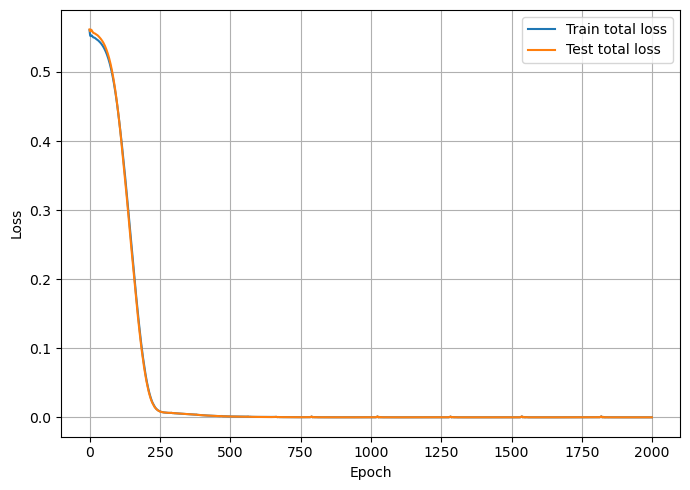

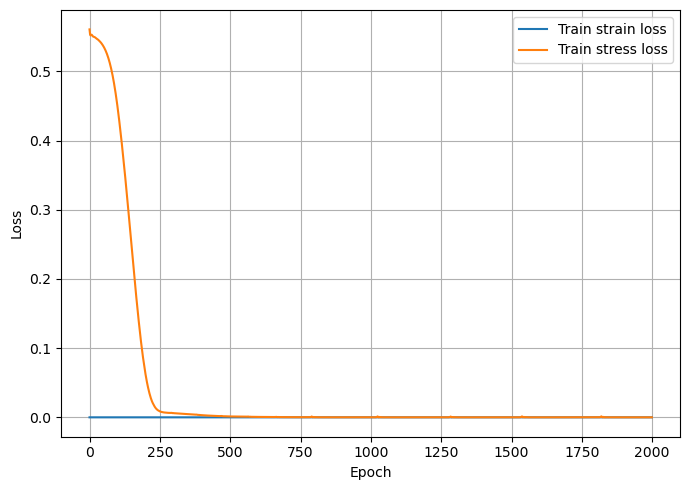

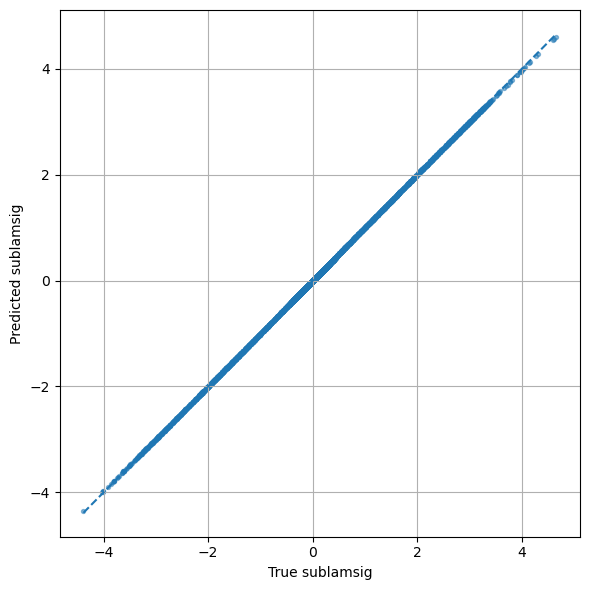

In [20]:
import numpy as np
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


class material:

    def __init__(self, E11, E22, E33, v12, v13, v23, G12, G23, G13):
        self.E11 = E11
        self.E22 = E22
        self.E33 = E33
        self.v12 = v12
        self.v13 = v13
        self.v23 = v23
        self.G12 = G12
        self.G23 = G23
        self.G13 = G13
        self.layup = np.array([0, 45, 90, 135], dtype=np.float64)
        self.nplies = self.layup.size

    def plymat(self):
        v12 = self.v12
        v13 = self.v13
        v23 = self.v23

        v21 = v12 * self.E22 / self.E11
        v32 = v23 * self.E33 / self.E22
        v31 = v13 * self.E33 / self.E11

        self.v21 = v21
        self.v32 = v32
        self.v31 = v31

        S = 1.0 - v12 * v21 - v23 * v32 - v31 * v13 - 2.0 * v21 * v32 * v13

        C11 = (1.0 - v23 * v32) * self.E11 / S
        C12 = (v21 + v31 * v23) * self.E11 / S
        C13 = (v31 + v21 * v32) * self.E11 / S
        C22 = (1.0 - v31 * v13) * self.E22 / S
        C23 = (v32 + v31 * v12) * self.E22 / S
        C33 = (1.0 - v12 * v21) * self.E33 / S
        C44 = self.G12
        C55 = self.G23
        C66 = self.G13

        lawMat = np.zeros((6, 6), dtype=np.float64)
        lawMat[0, 0] = C11
        lawMat[1, 1] = C22
        lawMat[2, 2] = C33
        lawMat[0, 1] = C12
        lawMat[1, 0] = C12
        lawMat[0, 2] = C13
        lawMat[2, 0] = C13
        lawMat[1, 2] = C23
        lawMat[2, 1] = C23
        lawMat[3, 3] = C44
        lawMat[4, 4] = C55
        lawMat[5, 5] = C66

        return lawMat

    def materialvec(self):
        self.sublamvec = np.zeros((self.nplies, 9), dtype=np.float64)

        for n in range(self.nplies):
            theta = np.deg2rad(self.layup[n])
            c = np.cos(theta)
            s = np.sin(theta)

            R = np.array([
                [c, -s, 0.0],
                [s,  c, 0.0],
                [0.0, 0.0, 1.0]
            ], dtype=np.float64)

            ef1 = R[:, 0]
            ef2 = R[:, 1]
            ef3 = np.cross(ef1, ef2)

            self.sublamvec[n, 0:3] = ef1
            self.sublamvec[n, 3:6] = ef2
            self.sublamvec[n, 6:9] = ef3

    def voigt_to_matrix(self, vec):
        matrix = np.zeros((3, 3), dtype=np.float64)

        matrix[0, 0] = vec[0]
        matrix[1, 1] = vec[1]
        matrix[2, 2] = vec[2]

        matrix[0, 1] = 0.5 * vec[3]
        matrix[1, 2] = 0.5 * vec[4]
        matrix[0, 2] = 0.5 * vec[5]

        matrix[1, 0] = 0.5 * vec[3]
        matrix[2, 1] = 0.5 * vec[4]
        matrix[2, 0] = 0.5 * vec[5]

        return matrix

    def matrix_to_voigt(self, matrix):
        vec = np.zeros(6, dtype=np.float64)

        vec[0] = matrix[0, 0]
        vec[1] = matrix[1, 1]
        vec[2] = matrix[2, 2]

        vec[3] = matrix[0, 1] + matrix[1, 0]
        vec[4] = matrix[1, 2] + matrix[2, 1]
        vec[5] = matrix[0, 2] + matrix[2, 0]

        return vec

    def transform(self, a1, a2, a3, Q, b1, b2, b3):
        L = np.zeros((3, 3), dtype=np.float64)

        L[0, 0] = np.dot(a1, b1)
        L[0, 1] = np.dot(a1, b2)
        L[0, 2] = np.dot(a1, b3)

        L[1, 0] = np.dot(a2, b1)
        L[1, 1] = np.dot(a2, b2)
        L[1, 2] = np.dot(a2, b3)

        L[2, 0] = np.dot(a3, b1)
        L[2, 1] = np.dot(a3, b2)
        L[2, 2] = np.dot(a3, b3)

        Qp = L.T @ Q @ L
        return Qp

    def constlaw(self, dEps):
        lawMat = self.plymat()
        dSig = np.zeros(6, dtype=np.float64)

        dSig[0] = lawMat[0, 0] * dEps[0] + lawMat[0, 1] * dEps[1] + lawMat[0, 2] * dEps[2]
        dSig[1] = lawMat[1, 0] * dEps[0] + lawMat[1, 1] * dEps[1] + lawMat[1, 2] * dEps[2]
        dSig[2] = lawMat[2, 0] * dEps[0] + lawMat[2, 1] * dEps[1] + lawMat[2, 2] * dEps[2]

        dSig[3] = lawMat[3, 3] * dEps[3]
        dSig[4] = lawMat[4, 4] * dEps[4]
        dSig[5] = lawMat[5, 5] * dEps[5]

        return dSig

    def sublam_sig_str(self, strainavg):
        strainavg = np.asarray(strainavg, dtype=np.float64).reshape(6)

        sublamsig = np.zeros((4, 6), dtype=np.float64)
        sublamstr = np.zeros((4, 6), dtype=np.float64)

        eg1 = np.array([1.0, 0.0, 0.0], dtype=np.float64)
        eg2 = np.array([0.0, 1.0, 0.0], dtype=np.float64)
        eg3 = np.array([0.0, 0.0, 1.0], dtype=np.float64)

        mat_g = self.voigt_to_matrix(strainavg)

        for n in range(4):
            ef1 = self.sublamvec[n, 0:3]
            ef2 = self.sublamvec[n, 3:6]
            ef3 = self.sublamvec[n, 6:9]

            mat_l = self.transform(eg1, eg2, eg3, mat_g, ef1, ef2, ef3)
            eps = self.matrix_to_voigt(mat_l)
            sig = self.constlaw(eps)

            sublamstr[n, :] = eps
            sublamsig[n, :] = sig

        return sublamsig, sublamstr


def voigt_to_matrix_torch(vec):
    B = vec.shape[0]
    M = torch.zeros(B, 3, 3, dtype=vec.dtype, device=vec.device)

    M[:, 0, 0] = vec[:, 0]
    M[:, 1, 1] = vec[:, 1]
    M[:, 2, 2] = vec[:, 2]

    M[:, 0, 1] = 0.5 * vec[:, 3]
    M[:, 1, 0] = 0.5 * vec[:, 3]

    M[:, 1, 2] = 0.5 * vec[:, 4]
    M[:, 2, 1] = 0.5 * vec[:, 4]

    M[:, 0, 2] = 0.5 * vec[:, 5]
    M[:, 2, 0] = 0.5 * vec[:, 5]

    return M


def matrix_to_voigt_torch(M):
    B = M.shape[0]
    v = torch.zeros(B, 6, dtype=M.dtype, device=M.device)

    v[:, 0] = M[:, 0, 0]
    v[:, 1] = M[:, 1, 1]
    v[:, 2] = M[:, 2, 2]
    v[:, 3] = M[:, 0, 1] + M[:, 1, 0]
    v[:, 4] = M[:, 1, 2] + M[:, 2, 1]
    v[:, 5] = M[:, 0, 2] + M[:, 2, 0]

    return v


class DifferentiableStrainTransform(nn.Module):
    def __init__(self, layup_deg):
        super().__init__()
        self.nplies = len(layup_deg)

        R_all = []
        for ang in layup_deg:
            theta = np.deg2rad(ang)
            c = np.cos(theta)
            s = np.sin(theta)
            R = np.array([
                [c, -s, 0.0],
                [s,  c, 0.0],
                [0.0, 0.0, 1.0]
            ], dtype=np.float32)
            R_all.append(R)

        self.register_buffer("R_all", torch.tensor(np.array(R_all), dtype=torch.float32))

    def forward(self, strain_global):
        eps_g = voigt_to_matrix_torch(strain_global)
        out = []

        for p in range(self.nplies):
            R = self.R_all[p].unsqueeze(0).expand(eps_g.shape[0], 3, 3)
            eps_l = R.transpose(1, 2) @ eps_g @ R
            out.append(matrix_to_voigt_torch(eps_l))

        return torch.stack(out, dim=1)


class PlyConstitutiveNet(nn.Module):
    def __init__(self, in_dim=6, hidden_dim=64, out_dim=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, eps_local):
        return self.net(eps_local)


class PhysicsAwarePRNN(nn.Module):
    def __init__(self, layup_deg, hidden_dim=64):
        super().__init__()
        self.transform = DifferentiableStrainTransform(layup_deg)
        self.nplies = len(layup_deg)
        self.ply_net = PlyConstitutiveNet(in_dim=6, hidden_dim=hidden_dim, out_dim=6)

    def forward(self, strain_global):
        sublamstr = self.transform(strain_global)

        ply_sig = []
        for p in range(self.nplies):
            sig_p = self.ply_net(sublamstr[:, p, :])
            ply_sig.append(sig_p)

        sublamsig = torch.stack(ply_sig, dim=1)
        return sublamstr, sublamsig


def dual_loss(pred_str, true_str, pred_sig, true_sig, w_str=1.0, w_sig=1.0):
    loss_str = torch.mean((pred_str - true_str) ** 2)
    loss_sig = torch.mean((pred_sig - true_sig) ** 2)
    loss = w_str * loss_str + w_sig * loss_sig
    return loss, loss_str, loss_sig


def generate_dual_dataset(material_obj, n_samples=2000, strain_min=-0.01, strain_max=0.01):
    X = []
    Y_str = []
    Y_sig = []

    for _ in range(n_samples):
        strain = np.random.uniform(strain_min, strain_max, size=6)
        sublamsig, sublamstr = material_obj.sublam_sig_str(strain)

        X.append(strain)
        Y_str.append(sublamstr)
        Y_sig.append(sublamsig)

    return (
        np.array(X, dtype=np.float32),
        np.array(Y_str, dtype=np.float32),
        np.array(Y_sig, dtype=np.float32),
    )


torch.manual_seed(0)
np.random.seed(0)

IM7 = material(
    E11=161, E22=10, E33=10,
    v12=0.3, v13=0.3, v23=0.43,
    G12=5, G13=5, G23=3.4
)
IM7.materialvec()

X, Y_str, Y_sig = generate_dual_dataset(
    IM7,
    n_samples=4000,
    strain_min=-0.02,
    strain_max=0.02
)

n_train = int(0.8 * len(X))

X_train = torch.tensor(X[:n_train], dtype=torch.float32)
Ystr_train = torch.tensor(Y_str[:n_train], dtype=torch.float32)
Ysig_train = torch.tensor(Y_sig[:n_train], dtype=torch.float32)

X_test = torch.tensor(X[n_train:], dtype=torch.float32)
Ystr_test = torch.tensor(Y_str[n_train:], dtype=torch.float32)
Ysig_test = torch.tensor(Y_sig[n_train:], dtype=torch.float32)

model = PhysicsAwarePRNN(layup_deg=[0, 45, 90, 135], hidden_dim=64)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 2000
loss_hist = []
loss_str_hist = []
loss_sig_hist = []
test_hist = []

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()

    pred_str, pred_sig = model(X_train)
    loss, loss_str, loss_sig = dual_loss(
        pred_str, Ystr_train,
        pred_sig, Ysig_train,
        w_str=1.0,
        w_sig=1.0
    )

    loss.backward()
    optimizer.step()

    loss_hist.append(loss.item())
    loss_str_hist.append(loss_str.item())
    loss_sig_hist.append(loss_sig.item())

    model.eval()
    with torch.no_grad():
        pred_str_te, pred_sig_te = model(X_test)
        test_loss, _, _ = dual_loss(
            pred_str_te, Ystr_test,
            pred_sig_te, Ysig_test,
            w_str=1.0,
            w_sig=1.0
        )
        test_hist.append(test_loss.item())

    if epoch % 200 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"train = {loss.item():.6e} | "
            f"strain = {loss_str.item():.6e} | "
            f"stress = {loss_sig.item():.6e} | "
            f"test = {test_loss.item():.6e}"
        )

strain_test = np.array([0.01, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
strain_test_t = torch.tensor(strain_test, dtype=torch.float32).unsqueeze(0)

model.eval()
with torch.no_grad():
    pred_str, pred_sig = model(strain_test_t)

pred_str_np = pred_str[0].cpu().numpy()
pred_sig_np = pred_sig[0].cpu().numpy()

true_sig_np, true_str_np = IM7.sublam_sig_str(strain_test)

print("\nPredicted sublamstr:")
print(pred_str_np)

print("\nTrue sublamstr:")
print(true_str_np)

print("\nPredicted sublamsig:")
print(pred_sig_np)

print("\nTrue sublamsig:")
print(true_sig_np)

plt.figure(figsize=(7, 5))
plt.plot(loss_hist, label="Train total loss")
plt.plot(test_hist, label="Test total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(loss_str_hist, label="Train strain loss")
plt.plot(loss_sig_hist, label="Train stress loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

with torch.no_grad():
    _, pred_sig_test = model(X_test)

pred_sig_test_np = pred_sig_test.cpu().numpy().reshape(-1)
true_sig_test_np = Ysig_test.cpu().numpy().reshape(-1)

plt.figure(figsize=(6, 6))
plt.scatter(true_sig_test_np, pred_sig_test_np, s=8, alpha=0.5)
mn = min(true_sig_test_np.min(), pred_sig_test_np.min())
mx = max(true_sig_test_np.max(), pred_sig_test_np.max())
plt.plot([mn, mx], [mn, mx], "--")
plt.xlabel("True sublamsig")
plt.ylabel("Predicted sublamsig")
plt.grid(True)
plt.tight_layout()
plt.show()